In [19]:
import numpy as np
from minio import Minio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import io

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_theme(style="whitegrid")

In [20]:
client = Minio(
    "202.4.114.56:9000",
    access_key="gazu",
    secret_key="asdf1234",
    secure=False
)

bucket = "padakhep-lakehouse"
object_name = "datamart/Credit_Worthiness/Schedule_Pattern_Dataset.parquet"

# Check object metadata
stat = client.stat_object(bucket, object_name)

print("Object size:", stat.size)
print("ETag:", stat.etag)

# Download the object
response = client.get_object(bucket, object_name)

try:
    data = response.read()
finally:
    response.close()
    response.release_conn()

print("Downloaded size:", len(data))

# Make sure the full object was downloaded
if len(data) != stat.size:
    raise ValueError(
        f"Incomplete download: expected {stat.size} bytes, "
        f"but received {len(data)} bytes"
    )

df = pd.read_parquet(
    io.BytesIO(data),
    engine="pyarrow"
)

df.head()


Object size: 30833654
ETag: c058c116e28bc28c7e909c95014faf28-6
Downloaded size: 30833654


,member_id,name,dateofbirth,gender,maritial_status,admission_date,education,occupation,alternative_occupation,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,home_owner_type,year_of_rent,farm_land_amt,loan_id,loan_cycle_no,loan_Component,loan_use_sources,loan_amount,disbursed_date,start_date,end_date,installmenttype,totalInstallmentcount,transaction_count,paymentdaycount,last_paid_date,installment_1,installment_2,installment_3,installment_4,installment_5,installment_6,installment_7,installment_8,installment_9,installment_10,installment_11,installment_12,installment_13,installment_14,installment_15,installment_16,installment_17,installment_18,installment_19,installment_20,installment_21,installment_22,installment_23,installment_24,installment_25,installment_26,installment_27,installment_28,installment_29,installment_30,installment_31,installment_32,installment_33,installment_34,installment_35,installment_36,installment_37,installment_38,installment_39,installment_40,installment_41,installment_42,installment_43,installment_44,installment_45,installment_46,installment_47,installment_48,installment_49,installment_50,installment_51,installment_52,installment_53,installment_54,installment_55,installment_56,installment_57,installment_58,installment_59,installment_60,installment_61,installment_62,installment_63,installment_64,installment_65,installment_66,installment_67,installment_68,installment_69,installment_70,installment_71,installment_72,installment_73,installment_74,installment_75,installment_76,installment_77,installment_78,installment_79,installment_80,installment_81,installment_82,installment_83,installment_84,installment_85,installment_86,installment_87,installment_88,installment_89,installment_90,installment_91
0,302095,Mst:Nasima Begum,1985-08-19,Female,Married,2019-05-06,Pre-Primary,Agriculture,krisi,3,1,30000.0,360000.0,120000.0,240000.0,Own,0,8,2235249,8,JAGORON,"<table align=""center"" border=""1"" cellpadding=""...",40000.00,2026-06-17,2026-07-01,2027-05-12,Weekly,46,46,1,2026-06-29,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,1339749,NAJMA BEGUM,1984-01-01,Female,Married,2026-06-03,Secondary,Housewife,,4,2,100000.0,1200000.0,450000.0,750000.0,Own,0,50,2219692,1,JAGORON,"<table align=""center"" border=""1"" cellpadding=""...",90000.00,2026-06-08,2026-07-12,2027-06-13,Mounthly,12,13,2,2026-06-29,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,1137258,Mohammad Mofiz,1968-05-10,Male,Married,2025-05-07,Higher-Secondary,Business,Business,5,2,80000.0,960000.0,360000.0,600000.0,Own,0,100,2211009,2,AGROSOR,"<table align=""center"" border=""1"" cellpadding=""...",300000.00,2026-05-21,2026-06-17,2027-05-19,Mounthly,12,12,1,2026-06-29,Bokeya,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,N

In [21]:
df.shape

(299870, 122)

In [98]:
df=df.drop_duplicates(subset=['loan_id'], keep='first')
df.shape

(295580, 122)

In [99]:
df['last_paid_date'] = pd.to_datetime(df['last_paid_date'])
df['end_date'] = pd.to_datetime(df['end_date'])
df['dateofbirth'] = pd.to_datetime(df['dateofbirth'])
df['admission_date'] = pd.to_datetime(df['admission_date'])

df['days_since_last_scheduled'] = (df['last_paid_date'] - df['end_date']).dt.days

In [100]:
df.tail()

,member_id,name,dateofbirth,gender,maritial_status,admission_date,education,occupation,alternative_occupation,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,home_owner_type,year_of_rent,farm_land_amt,loan_id,loan_cycle_no,loan_Component,loan_use_sources,loan_amount,disbursed_date,start_date,end_date,installmenttype,totalInstallmentcount,transaction_count,paymentdaycount,last_paid_date,installment_1,installment_2,installment_3,installment_4,installment_5,installment_6,installment_7,installment_8,installment_9,installment_10,installment_11,installment_12,installment_13,installment_14,installment_15,installment_16,installment_17,installment_18,installment_19,installment_20,installment_21,installment_22,installment_23,installment_24,installment_25,installment_26,installment_27,installment_28,installment_29,installment_30,installment_31,installment_32,installment_33,installment_34,installment_35,installment_36,installment_37,installment_38,installment_39,installment_40,installment_41,installment_42,installment_43,installment_44,installment_45,installment_46,installment_47,installment_48,installment_49,installment_50,installment_51,installment_52,installment_53,installment_54,installment_55,installment_56,installment_57,installment_58,installment_59,installment_60,installment_61,installment_62,installment_63,installment_64,installment_65,installment_66,installment_67,installment_68,installment_69,installment_70,installment_71,installment_72,installment_73,installment_74,installment_75,installment_76,installment_77,installment_78,installment_79,installment_80,installment_81,installment_82,installment_83,installment_84,installment_85,installment_86,installment_87,installment_88,installment_89,installment_90,installment_91,days_since_last_scheduled
299865,683768,Asma begum,1972-05-02,Female,Married,2023-02-09,Pre-Primary,Housewife,,5,3,46000.0,552000.0,275000.0,271000.0,Own,0,15,1542655,5,JAGORON,"<table align=""center"" border=""1"" cellpadding=""...",160000.00,2024-11-17,2024-12-23,2025-11-17,Mounthly,12,NaN,NaN,2025-08-13,Bokeya,Bokeya,Bokeya,Bokeya,Regular,Bokeya,Bokeya,Advance,Advance,Advance,Advance,Advance,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,-96
299866,679050,MD NURUDDIN,1984-01-02,Male,Married,2023-02-05,Higher-Secondary,Business,Krishi,4,2,150000.0,1800000.0,75000.0,1725000.0,Own,0,100,1542651,3,AGROSOR,"<table align=""center"" border=""1"" cellpadding=""...",550000.00,2024-11-17,2024-12-17,2025-11-18,Mounthly,12,NaN,NaN,2025-10-08,Bokeya,Bokeya,Bokeya,Bokeya,Bokeya,Bokeya,Bokeya,Bokeya,Bokeya,Bokeya,Advance,Advance,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,-41
299867,48916,Md Mizanur Rahman,1967-10-20,Male,Married,2012-11-12,SSC,Business,business,4,2,70000.0,840000.0,360000.0,480000.0,Own,0,180,1542642,16,JAGORON,"<table align=""center"" border=""1"" cellpadding=""...",100000.00,2024-11-17,2024-12-15,2025-11-16,Mounthly,12,NaN,NaN,2025-10-05,Advance,Bokeya,Advance,Advance,Advance,Advance,Regular,Advance,Advance,Advance,Advance,Advance,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,

In [101]:
print("Total loans", len(df))
print("Total Member", df['member_id'].nunique())
print('Average loan Amount', df['loan_amount'].mean())


Total loans 295580
Total Member 274161
Average loan Amount 117651.32478516814


In [102]:
installment_cols = [c for c in df.columns if c.startswith('installment_')]
print( len(installment_cols), "found the following columns:")

91 found the following columns:


In [103]:
print(df.shape), print(df.dtypes)

(295580, 123)
member_id                             int64
name                                 object
dateofbirth                  datetime64[ns]
gender                               object
maritial_status                      object
                                  ...      
installment_88                       object
installment_89                       object
installment_90                       object
installment_91                       object
days_since_last_scheduled             int64
Length: 123, dtype: object


(None, None)

In [104]:
df.columns

Index(['member_id', 'name', 'dateofbirth', 'gender', 'maritial_status',
       'admission_date', 'education', 'occupation', 'alternative_occupation',
       'total_family_member',
       ...
       'installment_83', 'installment_84', 'installment_85', 'installment_86',
       'installment_87', 'installment_88', 'installment_89', 'installment_90',
       'installment_91', 'days_since_last_scheduled'],
      dtype='object', length=123)

In [105]:
missing=df.isna().sum().sort_values(ascending=False)
missing_pct = (missing/len(df) * 100).round(2)
missing_summary =pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_summary.head(20))

                missing_count  missing_pct
installment_91         295568       100.00
installment_85         295565        99.99
installment_87         295565        99.99
installment_78         295565        99.99
installment_83         295565        99.99
installment_82         295565        99.99
installment_81         295565        99.99
installment_77         295565        99.99
installment_88         295565        99.99
installment_75         295565        99.99
installment_76         295565        99.99
installment_80         295565        99.99
installment_89         295565        99.99
installment_90         295565        99.99
installment_74         295565        99.99
installment_86         295565        99.99
installment_79         295565        99.99
installment_84         295565        99.99
installment_73         295565        99.99
installment_72         295564        99.99


In [106]:
non_payment_missing = missing_summary.drop(index=installment_cols, errors='ignore')
non_payment_missing = non_payment_missing[non_payment_missing['missing_count'] > 0]
non_payment_missing

,missing_count,missing_pct
paymentdaycount,7780,2.63
transaction_count,7780,2.63


In [107]:
df[['loan_amount', 'total_monthly_income', 'yearly_total_income',
          'yearly_total_savings', 'transaction_count', 'paymentdaycount']].describe()

,total_monthly_income,yearly_total_income,yearly_total_savings,transaction_count,paymentdaycount
count,2.955800e+05,2.955800e+05,2.955800e+05,287800.000000,287800.000000
mean,8.192363e+04,9.830836e+05,5.855904e+05,37.143902,27.399128
std,2.058846e+06,2.470615e+07,4.994606e+06,17.518994,13.869695
min,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.000000
25%,3.800000e+04,4.560000e+05,1.800000e+05,14.000000,12.000000
50%,5.000000e+04,6.000000e+05,3.000000e+05,46.000000,33.000000
75%,7.000000e+04,8.400000e+05,4.800000e+05,47.000000,40.000000
max,9.800000e+08,1.176000e+10,1.790400e+09,127.000000,105.000000


In [108]:
#categorical breakdown
for col in ['gender', 'maritial_status', 'education', 'occupation',
            'home_owner_type', 'installmenttype', 'loan_component']:
    if col in df.columns:
        print(f"\n--- {col} value counts ---")
        print(df[col].value_counts(dropna=False).head(15))


--- gender value counts ---
gender
Female    259330
Male       36250
Name: count, dtype: int64

--- maritial_status value counts ---
maritial_status
Married      289881
Single         2686
Unmarried      2504
Widowed         417
Divorced         92
Name: count, dtype: int64

--- education value counts ---
education
Pre-Primary         135724
Primary              69959
Secondary            40066
JSC                  11334
Higher-Secondary      9878
PSC                   8395
SSC                   6663
Graduation            4515
HSC                   3032
Illiterate            2217
Literacy              1131
Post-Graduation        835
Honors                 591
Masters                588
Degree                 528
Name: count, dtype: int64

--- occupation value counts ---
occupation
Housewife        222202
Business          50753
Agriculture        9637
Service            8186
Self-Employed      3579
Others             1223
Name: count, dtype: int64

--- home_owner_type value counts ---

In [109]:
loan_counts = (df.groupby('member_id')['loan_id'].nunique().reset_index(name='loan_count'))
multiple_loan_members = loan_counts[
    loan_counts["loan_count"] > 1
]

multiple_loan_members.sort_values(ascending=False, by='loan_count')

,member_id,loan_count
5340,66851,5
68373,630329,5
5297,66678,5
30364,315502,5
5302,66696,5
...,...,...
240,4459,2
245,4509,2
246,4529,2
251,4620,2


In [110]:
payment_cols = [f"installment_{i}" for i in range(1, 92)]

df["install_count"] = df[payment_cols].notna().sum(axis=1)

result = df.loc[
    df["install_count"].idxmax(),
    ["member_id", "name", "loan_id", "install_count"]
]

print(result)


member_id                     265982
name             Mst.Rowsonaka Begum
loan_id                      1977430
install_count                     91
Name: 2198, dtype: object


In [111]:
payment_cols = [f"installment_{i}" for i in range(1, 92)]
bokeya = df[payment_cols].eq("Bokeya")

has_3_consecutive = (
    bokeya.astype(int)
    .rolling(window=3, axis=1)
    .sum()
    .eq(3)
    .any(axis=1)
)

result = df.loc[
    has_3_consecutive,
    ["member_id", "name", "loan_id"]
].drop_duplicates("member_id")

result

C:\Users\User\AppData\Local\Temp\ipykernel_28856\4236080870.py:5: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  bokeya.astype(int)


,member_id,name,loan_id
26,1122252,Mst Jobeda Begum,2169238
31,984021,MST. Laki Akter,2162558
50,982821,MSt.Abeda khatun,2151759
78,388770,Mst. Rubina Khatun,2141770
80,272973,Mst.Monuga,2141812
...,...,...,...
299862,677979,MAHIMA BEGUM,1542724
299863,1031674,MST: MONIRA KHATUN,1542692
299865,683768,Asma begum,1542655
299866,679050,MD NURUDDIN,1542651


In [112]:
payment_cols = [f"installment_{i}" for i in range(1, 92)]
bokeya = df[payment_cols].eq("Bokeya")

has_4_consecutive = (
    bokeya.astype(int)
    .rolling(window=4, axis=1)
    .sum()
    .eq(4)
    .any(axis=1)
)

result = df.loc[
    has_4_consecutive,
    ["member_id", "name", "loan_id"]
].drop_duplicates("member_id")

result


C:\Users\User\AppData\Local\Temp\ipykernel_28856\140046407.py:5: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  bokeya.astype(int)


,member_id,name,loan_id
26,1122252,Mst Jobeda Begum,2169238
31,984021,MST. Laki Akter,2162558
80,272973,Mst.Monuga,2141812
86,1168036,Anita Rani,2140267
89,824049,Hossain Ahammad,2136875
...,...,...,...
299861,157924,Sree Milon Kumar Sharma,1542736
299863,1031674,MST: MONIRA KHATUN,1542692
299865,683768,Asma begum,1542655
299866,679050,MD NURUDDIN,1542651


In [113]:
# has_4_consecutive in occupation
# Get members/loans having 4 consecutive Bokeya
result_4 = df.loc[
    has_4_consecutive,
    ["member_id", "occupation"]
].drop_duplicates("member_id")

# Count unique members in each occupation
occupation_counts = (
    result_4.groupby("occupation")["member_id"]
    .nunique()
    .sort_values(ascending=False)
)

# Top 7 occupations
top = occupation_counts.head(7).reset_index()
top.columns = ["occupation", "member_count"]

# Pie chart
fig = px.pie(
    top,
    names="occupation",
    values="member_count",
    title="Top 7 Occupations with 4 Consecutive Bokeya",
    hole=0.4
)
fig.show()


In [115]:
def max_consecutive_bokeya(row):
    values = row.eq("Bokeya")
    groups = (~values).cumsum()
    return values.groupby(groups).sum().max()

df["max_consecutive_bokeya"] = df[payment_cols].apply(
    max_consecutive_bokeya,
    axis=1
)

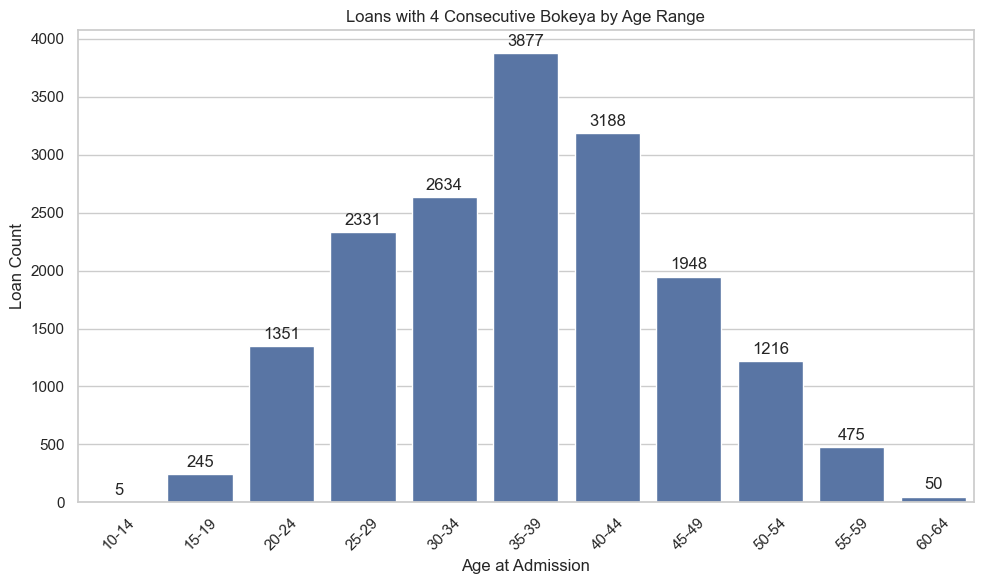

In [116]:
df['age_at_admission'] = (df['admission_date'] - df['dateofbirth']).dt.days/365
age_4_bokeya = df.loc[
    df["max_consecutive_bokeya"] == 4
].copy()

bins = range(10, int(age_4_bokeya["age_at_admission"].max()) + 6, 5)

age_4_bokeya["age_range"] = pd.cut(
    age_4_bokeya["age_at_admission"],
    bins=bins,
    right=False,
    labels=[f"{i}-{i+4}" for i in bins[:-1]]
)

# Count unique loans
age_4_bokeya = (
    age_4_bokeya
    .groupby("age_range", observed=False)["loan_id"]
    .nunique()
    .reset_index(name="loan_count")
)

# Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=age_4_bokeya,
    x="age_range",
    y="loan_count"
)

# Show loan_count value on top of each bar
ax.bar_label(
    ax.containers[0],
    fmt="%d",
    padding=3
)

plt.title("Loans with 4 Consecutive Bokeya by Age Range")
plt.xlabel("Age at Admission")
plt.ylabel("Loan Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [117]:
youngest_age = df["age_at_admission"].min()
oldest_age = df["age_at_admission"].max()
print( 'youngest loanee member', youngest_age)
print( 'oldest loanee member', oldest_age)

youngest loanee member 0.9260273972602739
oldest loanee member 71.84383561643835


In [119]:
df[['loan_id','max_consecutive_bokeya']].sort_values(ascending=False, by='max_consecutive_bokeya')

,loan_id,max_consecutive_bokeya
64910,1800867,46
212854,1638026,46
35609,1836455,46
212489,1640028,46
211308,1639888,46
...,...,...
21,2172189,0
20,2178364,0
18,2184463,0
17,2186197,0


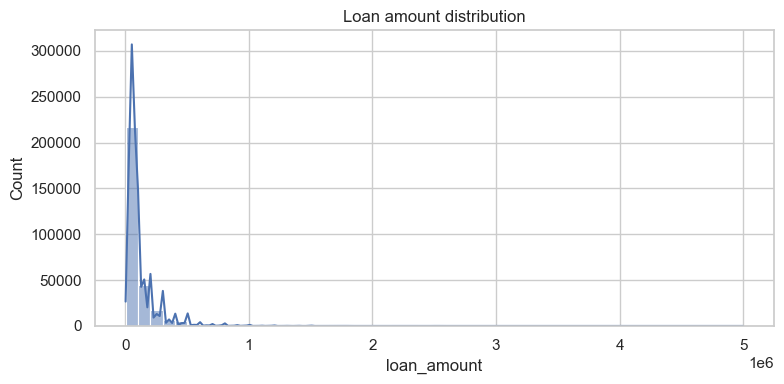

In [120]:
# loan amount distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['loan_amount'].dropna(), bins=50, kde=True)
plt.title('Loan amount distribution')
plt.tight_layout()
plt.show()

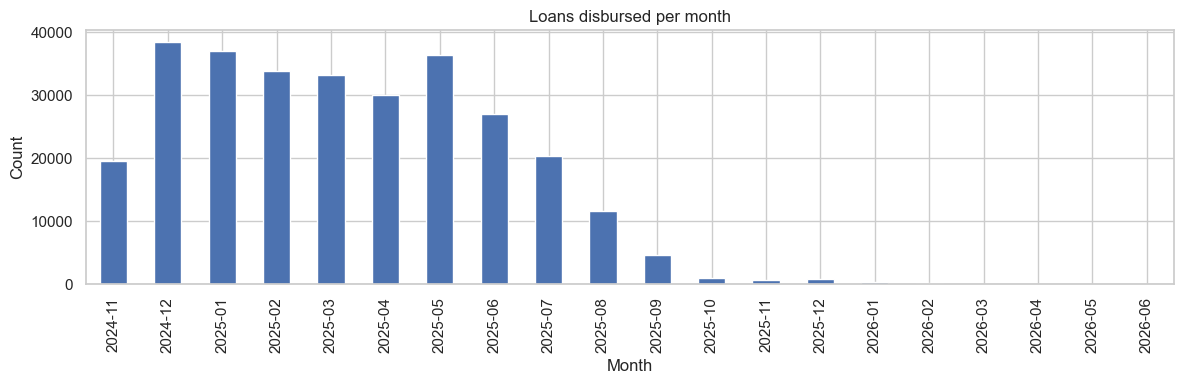

In [121]:
if 'disbursed_date' in df.columns:
    df['disbursed_month'] = pd.to_datetime(df['disbursed_date']).dt.to_period('M')
    monthly_counts = df['disbursed_month'].value_counts().sort_index()
    plt.figure(figsize=(12, 4))
    monthly_counts.plot(kind='bar')
    plt.title('Loans disbursed per month')
    plt.xlabel('Month')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

In [122]:
# http://118.179.149.162:8835/loan_application/apply/0?member_id=76168
if 'loan_cycle_no' in df.columns:
    print("\n--- Loan cycle number distribution ---")
    print(df['loan_cycle_no'].value_counts(dropna=False).sort_index().head(20))


--- Loan cycle number distribution ---
loan_cycle_no
1     122084
2      67660
3      34022
4      22631
5      14702
6      10408
7       7417
8       5322
9       3724
10      2407
11      1574
12       992
13       643
14       440
15       323
16       254
17       185
18       130
19        97
20        68
Name: count, dtype: int64



--- Overall installment_pattern distribution ---
installment_pattern
Regular    5039857
Advance    3588414
Bokeya     1567285
Name: count, dtype: int64
installment_pattern
Regular    49.43%
Advance     35.2%
Bokeya     15.37%
Name: count, dtype: object


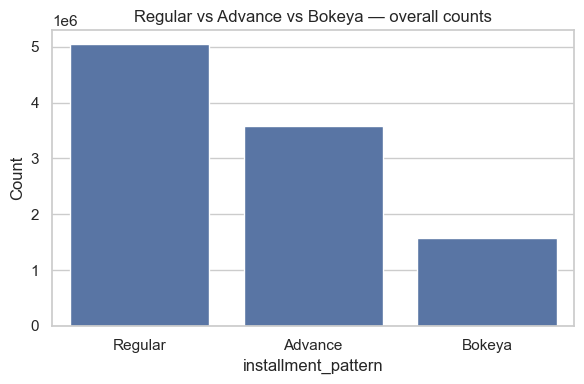

In [123]:
long_payments = df.melt(
    id_vars=['loan_id', 'member_id'],
    value_vars=installment_cols,
    var_name='installment',
    value_name='installment_pattern'
).dropna(subset=['installment_pattern'])

long_payments['installment_num'] = (
    long_payments['installment'].str.replace('installment_', '').astype(int)
)
print("\n--- Overall installment_pattern distribution ---")
pattern_counts = long_payments['installment_pattern'].value_counts()
print(pattern_counts)
print((pattern_counts / pattern_counts.sum() * 100).round(2).astype(str) + '%')

plt.figure(figsize=(6, 4))
sns.barplot(x=pattern_counts.index, y=pattern_counts.values)
plt.title('Regular vs Advance vs Bokeya — overall counts')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [124]:
member_all_regular = (
    long_payments.groupby('loan_id')['installment_pattern']   # <-- groups by loan, not member
    .apply(lambda x: (x == 'Regular').all())
)
all_regular_count = member_all_regular.sum()
print(f"Members with all Regular installment: {all_regular_count}")

Members with all Regular installment: 3537


In [125]:
df[df['loan_id'] ==1788883]

,member_id,name,dateofbirth,gender,maritial_status,admission_date,education,occupation,alternative_occupation,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,home_owner_type,year_of_rent,farm_land_amt,loan_id,loan_cycle_no,loan_Component,loan_use_sources,loan_amount,disbursed_date,start_date,end_date,installmenttype,totalInstallmentcount,transaction_count,paymentdaycount,last_paid_date,installment_1,installment_2,installment_3,installment_4,installment_5,installment_6,installment_7,installment_8,installment_9,installment_10,installment_11,installment_12,installment_13,installment_14,installment_15,installment_16,installment_17,installment_18,installment_19,installment_20,installment_21,installment_22,installment_23,installment_24,installment_25,installment_26,installment_27,installment_28,installment_29,installment_30,installment_31,installment_32,installment_33,installment_34,installment_35,installment_36,installment_37,installment_38,installment_39,installment_40,installment_41,installment_42,installment_43,installment_44,installment_45,installment_46,installment_47,installment_48,installment_49,installment_50,installment_51,installment_52,installment_53,installment_54,installment_55,installment_56,installment_57,installment_58,installment_59,installment_60,installment_61,installment_62,installment_63,installment_64,installment_65,installment_66,installment_67,installment_68,installment_69,installment_70,installment_71,installment_72,installment_73,installment_74,installment_75,installment_76,installment_77,installment_78,installment_79,installment_80,installment_81,installment_82,installment_83,installment_84,installment_85,installment_86,installment_87,installment_88,installment_89,installment_90,installment_91,days_since_last_scheduled,install_count,age_at_admission,max_consecutive_bokeya,disbursed_month
74637,507714,KAZI NAZRUL ISLAM,1977-01-01,Male,Married,2022-03-10,Pre-Primary,Business,Agriculture q,4,1,140000.0,1680000.0,1460000.0,220000.0,,0,25,1788883,5,AGROSOR,"<table align=""center"" border=""1"" cellpadding=""...",400000.00,2025-05-26,2025-06-17,2026-06-09,Weekly,46,46.0,46.0,2026-06-09,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,46,45.216438,0,2025-05


In [126]:
member_all_regular

loan_id
1542576    False
1542580    False
1542581    False
1542588    False
1542590    False
           ...  
2210469    False
2210543    False
2211009    False
2219692    False
2235249    False
Name: installment_pattern, Length: 295580, dtype: bool

In [127]:
# Check whether every transaction for each member is Regular
member_all_bokeya = (
    long_payments.groupby('loan_id')['installment_pattern']
    .apply(lambda x: (x == 'Bokeya').all())
)

all_bokeya_count = member_all_bokeya.sum()

print(f"Members with all Bokeya installment: {all_bokeya_count}")


Members with all Bokeya installment: 2672


In [128]:
member_all_bokeya

loan_id
1542576    False
1542580    False
1542581    False
1542588    False
1542590    False
           ...  
2210469    False
2210543    False
2211009    False
2219692    False
2235249    False
Name: installment_pattern, Length: 295580, dtype: bool

In [129]:
# Check whether every transaction for each member is Regular
member_all_advanced = (
    long_payments.groupby('loan_id')['installment_pattern']
    .apply(lambda x: (x == 'Advance').all())
)

all_advanced_count = member_all_advanced.sum()

print(f"Members with all Advance installment: {all_advanced_count}")


Members with all Advance installment: 14994


In [130]:
df[df['loan_id'] ==2235249]

,member_id,name,dateofbirth,gender,maritial_status,admission_date,education,occupation,alternative_occupation,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,home_owner_type,year_of_rent,farm_land_amt,loan_id,loan_cycle_no,loan_Component,loan_use_sources,loan_amount,disbursed_date,start_date,end_date,installmenttype,totalInstallmentcount,transaction_count,paymentdaycount,last_paid_date,installment_1,installment_2,installment_3,installment_4,installment_5,installment_6,installment_7,installment_8,installment_9,installment_10,installment_11,installment_12,installment_13,installment_14,installment_15,installment_16,installment_17,installment_18,installment_19,installment_20,installment_21,installment_22,installment_23,installment_24,installment_25,installment_26,installment_27,installment_28,installment_29,installment_30,installment_31,installment_32,installment_33,installment_34,installment_35,installment_36,installment_37,installment_38,installment_39,installment_40,installment_41,installment_42,installment_43,installment_44,installment_45,installment_46,installment_47,installment_48,installment_49,installment_50,installment_51,installment_52,installment_53,installment_54,installment_55,installment_56,installment_57,installment_58,installment_59,installment_60,installment_61,installment_62,installment_63,installment_64,installment_65,installment_66,installment_67,installment_68,installment_69,installment_70,installment_71,installment_72,installment_73,installment_74,installment_75,installment_76,installment_77,installment_78,installment_79,installment_80,installment_81,installment_82,installment_83,installment_84,installment_85,installment_86,installment_87,installment_88,installment_89,installment_90,installment_91,days_since_last_scheduled,install_count,age_at_admission,max_consecutive_bokeya,disbursed_month
0,302095,Mst:Nasima Begum,1985-08-19,Female,Married,2019-05-06,Pre-Primary,Agriculture,krisi,3,1,30000.0,360000.0,120000.0,240000.0,Own,0,8,2235249,8,JAGORON,"<table align=""center"" border=""1"" cellpadding=""...",40000.00,2026-06-17,2026-07-01,2027-05-12,Weekly,46,46.0,1.0,2026-06-29,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,-317,46,33.734247,0,2026-06


In [131]:
member_all_advanced

loan_id
1542576    False
1542580    False
1542581    False
1542588    False
1542590    False
           ...  
2210469    False
2210543     True
2211009    False
2219692     True
2235249     True
Name: installment_pattern, Length: 295580, dtype: bool

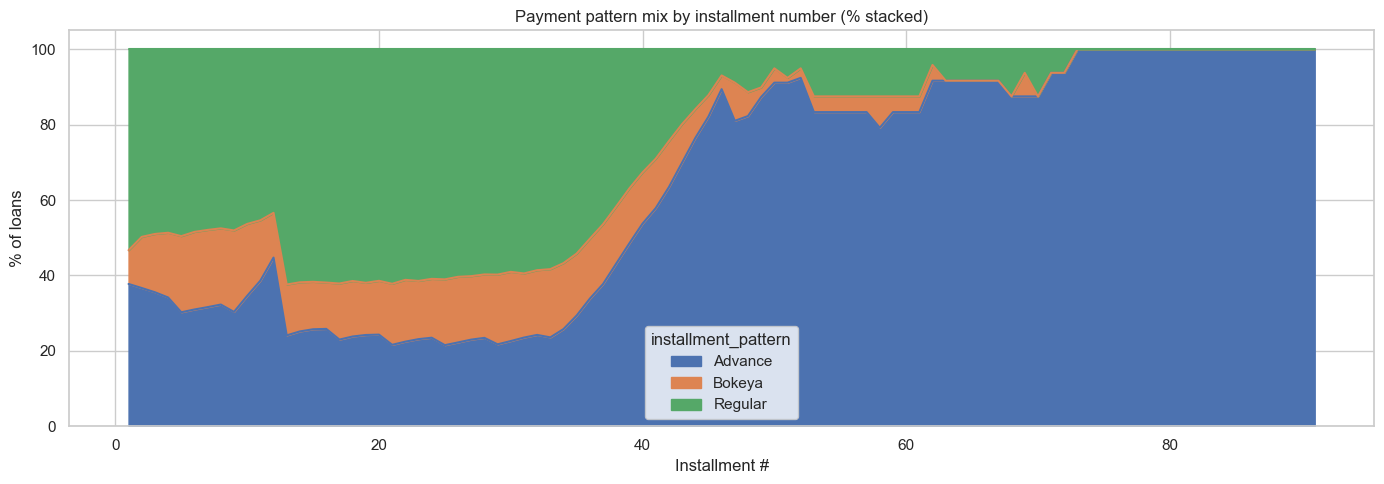

In [132]:
# Does the payment behaviour change as the loan progress
pattern_by_installment = (
    long_payments.groupby(['installment_num', 'installment_pattern'])
    .size()
    .unstack(fill_value=0)
)
pattern_pct_by_installment = pattern_by_installment.div(
    pattern_by_installment.sum(axis=1), axis=0
) * 100

plt.figure(figsize=(14, 5))
pattern_pct_by_installment.plot(kind='area', stacked=True, ax=plt.gca())
plt.title('Payment pattern mix by installment number (% stacked)')
plt.xlabel('Installment #')
plt.ylabel('% of loans')
plt.tight_layout()
plt.show()


--- Distribution of first missed/irregular installment ---
count    213863.000000
mean         11.261869
std          10.882070
min           1.000000
25%           3.000000
50%           7.000000
75%          17.000000
max          48.000000
Name: first_bokeya_installment, dtype: float64


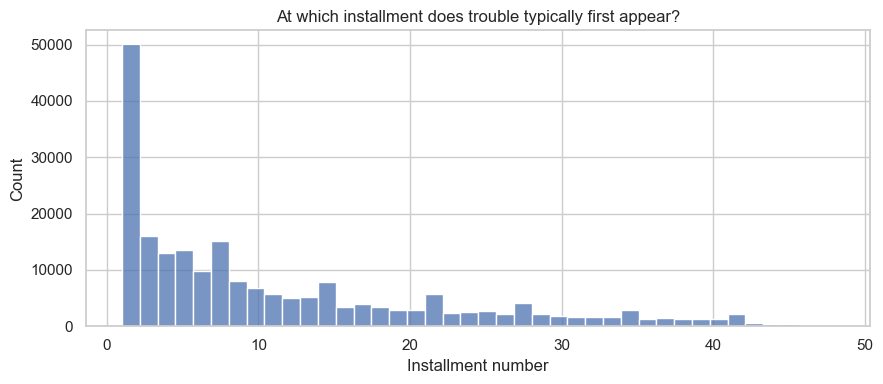

In [133]:
## When A loan goes first bokeya
first_bokeya = (
    long_payments[long_payments['installment_pattern'] == 'Bokeya']
    .groupby('loan_id')['installment_num']
    .min()
    .rename('first_bokeya_installment')
)

df = df.merge(first_bokeya, on='loan_id', how='left')

print("\n--- Distribution of first missed/irregular installment ---")
print(df['first_bokeya_installment'].describe())

plt.figure(figsize=(9, 4))
sns.histplot(df['first_bokeya_installment'].dropna(), bins=40)
plt.title('At which installment does trouble typically first appear?')
plt.xlabel('Installment number')
plt.tight_layout()
plt.show()

if 'loan_component' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='loan_component', y='first_bokeya_installment')
    plt.title('First trouble installment by loan component')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

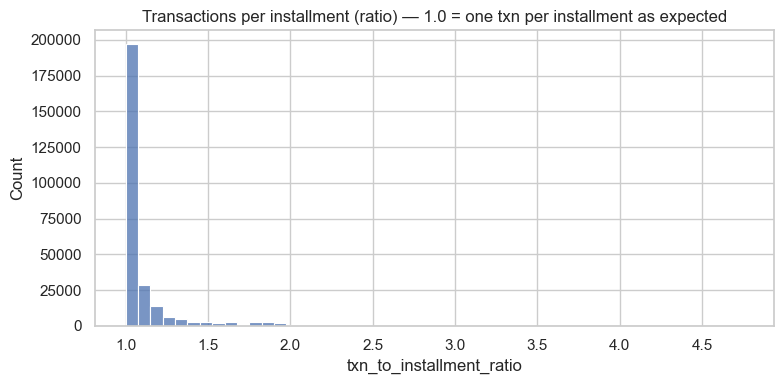

In [134]:
if 'transaction_count' in df.columns and 'totalInstallmentcount' in df.columns:
    df['txn_to_installment_ratio'] = df['transaction_count'] / df['totalInstallmentcount']
    plt.figure(figsize=(8, 4))
    sns.histplot(df['txn_to_installment_ratio'].dropna(), bins=50)
    plt.title('Transactions per installment (ratio) — 1.0 = one txn per installment as expected')
    plt.tight_layout()
    plt.show()

In [135]:
# bokeya/ missed percentage
loan_pattern_summary = (
    long_payments.groupby('loan_id')['installment_pattern']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .add_prefix('pct_')
)
df = df.merge(loan_pattern_summary, on='loan_id', how='left')

print("\n--- Loans with highest Bokeya (irregular/missed) rate ---")
if 'pct_Bokeya' in df.columns:
    print(df[['loan_id', 'member_id', 'loan_amount', 'pct_Bokeya']]
          .sort_values('pct_Bokeya', ascending=False).head(20))


--- Loans with highest Bokeya (irregular/missed) rate ---
        loan_id  member_id loan_amount  pct_Bokeya
188810  1660884    1086635   100000.00         1.0
95044   1766850     346328    35000.00         1.0
95058   1766784    1138415    60000.00         1.0
95070   1766730     551952    30000.00         1.0
222473  1625920     352694    20000.00         1.0
125102  1730475     931221   230000.00         1.0
222551  1623496     886741   250000.00         1.0
263410  1579148     895447    20000.00         1.0
95164   1766291    1136636    60000.00         1.0
95161   1766474     962026   200000.00         1.0
195407  1653593     867534   140000.00         1.0
94923   1764700      37936   280000.00         1.0
94920   1765042    1128650    55000.00         1.0
195482  1653910      94015   300000.00         1.0
195496  1653994    1068350   120000.00         1.0
195170  1653788     925110   120000.00         1.0
95348   1765115    1133859   400000.00         1.0
287165  1550581      36

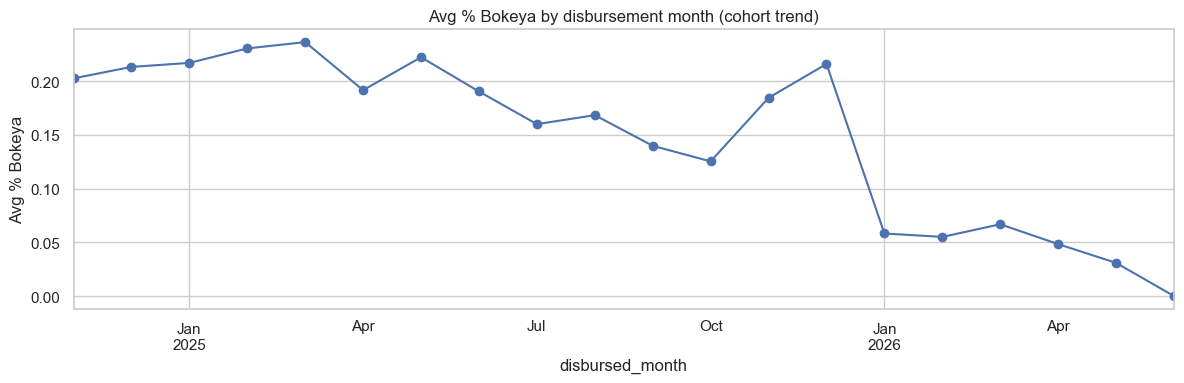

In [136]:
if 'disbursed_month' in df.columns and 'pct_Bokeya' in df.columns:
    cohort_quality = df.groupby('disbursed_month')['pct_Bokeya'].mean()
    plt.figure(figsize=(12, 4))
    cohort_quality.plot(kind='line', marker='o')
    plt.title('Avg % Bokeya by disbursement month (cohort trend)')
    plt.ylabel('Avg % Bokeya')
    plt.tight_layout()
    plt.show()

In [137]:
for col in ['occupation', 'education', 'gender', 'loan_component']:
    if col in df.columns and 'pct_Bokeya' in df.columns:
        summary = df.groupby(col)['pct_Bokeya'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        print(f"\n--- Avg % Bokeya by {col} ---")
        print(summary.head(15))


--- Avg % Bokeya by occupation ---
                   mean   count
occupation                     
Others         0.235608    1223
Service        0.220651    8186
Business       0.216781   50753
Housewife      0.205325  222202
Self-Employed  0.196751    3579
Agriculture    0.187077    9637

--- Avg % Bokeya by education ---
                      mean   count
education                         
Masters           0.271005     588
Graduation        0.263182    4515
Honors            0.258797     591
Post-Graduation   0.258668     835
Degree            0.257434     528
Higher-Secondary  0.240388    9878
Secondary         0.228852   40066
HSC               0.218790    3032
SSC               0.204685    6663
Pre-Primary       0.203475  135724
Primary           0.201681   69959
PHD               0.189211       9
Illiterate        0.187308    2217
JSC               0.180341   11334
Others            0.178450     115

--- Avg % Bokeya by gender ---
            mean   count
gender               

In [138]:
# Members with multiple loans: are they trending better or worse over time
member_loan_counts = df['member_id'].value_counts()
repeat_members = member_loan_counts[member_loan_counts > 1].index

if len(repeat_members) > 0 and 'disbursed_date' in df.columns:
    repeat_df = df[df['member_id'].isin(repeat_members)].sort_values(['member_id', 'disbursed_date'])
    repeat_df['loan_sequence'] = repeat_df.groupby('member_id').cumcount() + 1

    trend = repeat_df.groupby('loan_sequence')['pct_Bokeya'].mean()
    print(f"\n--- {len(repeat_members)} repeat members found ---")
    print("Avg % Bokeya by which loan number (1st, 2nd, 3rd...) for that member:")
    print(trend.head(10))


--- 19654 repeat members found ---
Avg % Bokeya by which loan number (1st, 2nd, 3rd...) for that member:
loan_sequence
1    0.214267
2    0.230566
3    0.246187
4    0.336712
5    0.354859
Name: pct_Bokeya, dtype: float64


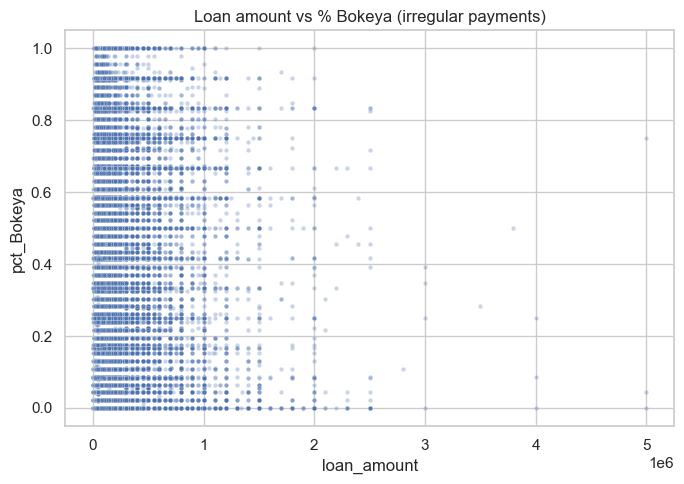

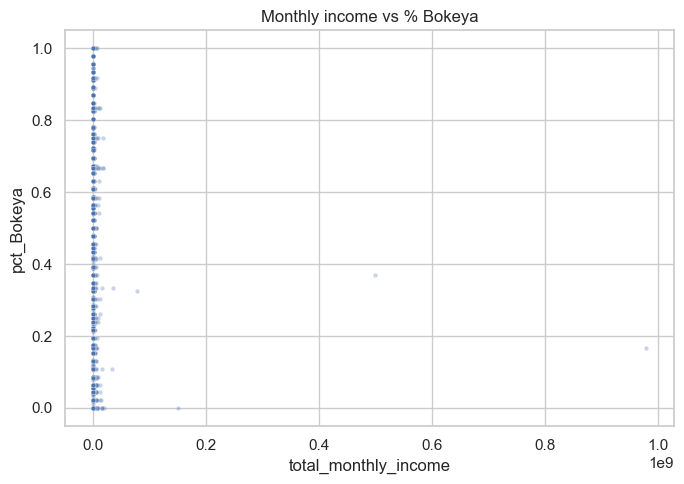

In [139]:
# does loan amount relate to repayment history
if 'pct_Bokeya' in df.columns:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x='loan_amount', y='pct_Bokeya', alpha=0.3, s=10)
    plt.title('Loan amount vs % Bokeya (irregular payments)')
    plt.tight_layout()
    plt.show()

# --- Does income relate to repayment quality? ---
if 'pct_Bokeya' in df.columns and 'total_monthly_income' in df.columns:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x='total_monthly_income', y='pct_Bokeya', alpha=0.3, s=10)
    plt.title('Monthly income vs % Bokeya')
    plt.tight_layout()
    plt.show()


--- Avg % Bokeya by loan cycle number ---
                   mean   count
loan_cycle_no                  
1              0.183981  122084
2              0.219513   67660
3              0.232005   34022
4              0.230745   22631
5              0.234509   14702
6              0.223742   10408
7              0.215227    7417
8              0.198570    5322
9              0.195437    3724
10             0.188042    2407
11             0.198311    1574
12             0.196561     992
13             0.229016     643
14             0.241675     440
15             0.222652     323
16             0.280854     254
17             0.317979     185
18             0.273746     130
19             0.272449      97
20             0.187127      68
21             0.314070      60
22             0.295081      52
23             0.340487      39
24             0.284353      27
25             0.230525      24
26             0.359483      23
27             0.314493      30
28             0.248876      

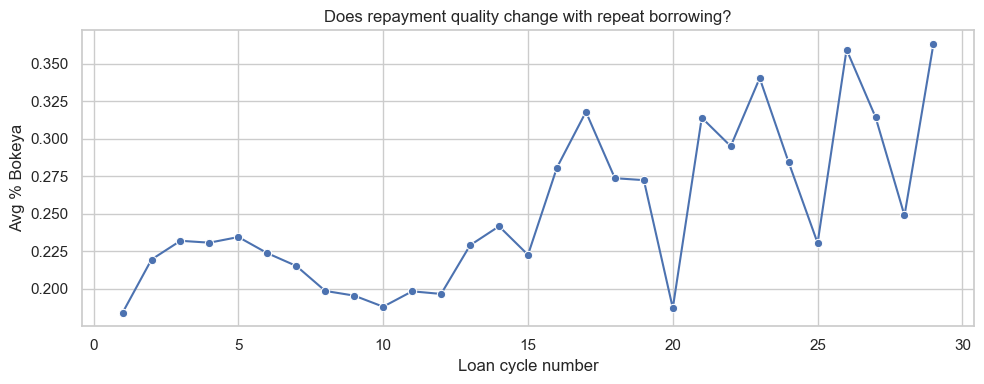

In [140]:
### Repeated Borrower Behaviour
if 'loan_cycle_no' in df.columns and 'pct_Bokeya' in df.columns:
    cycle_quality = df.groupby('loan_cycle_no')['pct_Bokeya'].agg(['mean', 'count'])
    cycle_quality = cycle_quality[cycle_quality['count'] >= 20]  # drop noisy small groups

    print("\n--- Avg % Bokeya by loan cycle number ---")
    print(cycle_quality)

    plt.figure(figsize=(10, 4))
    sns.lineplot(x=cycle_quality.index, y=cycle_quality['mean'], marker='o')
    plt.title('Does repayment quality change with repeat borrowing?')
    plt.xlabel('Loan cycle number')
    plt.ylabel('Avg % Bokeya')
    plt.tight_layout()
    plt.show()

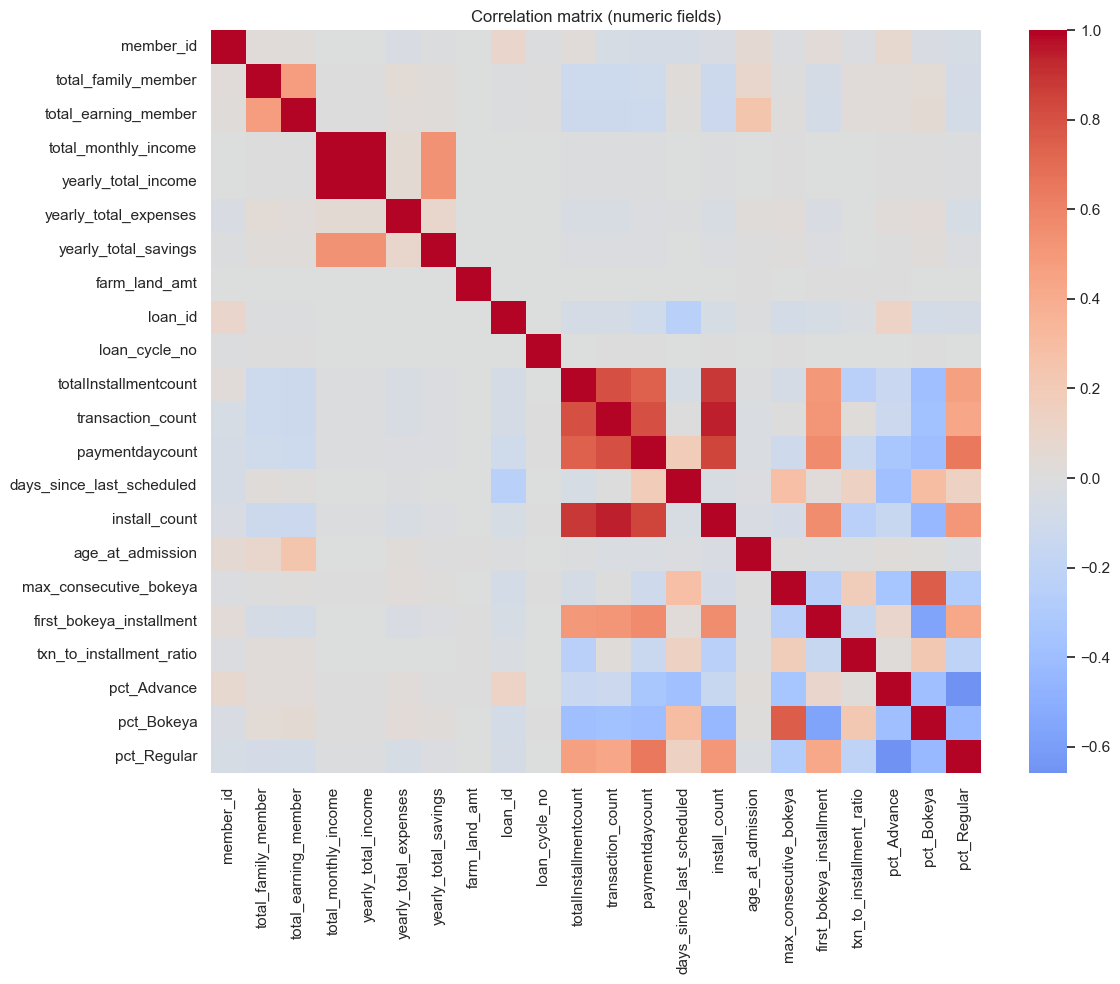

In [141]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in installment_cols][:25]  # cap for readability
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation matrix (numeric fields)')
plt.tight_layout()
plt.show()

In [142]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
cluster_features = ['loan_amount', 'total_monthly_income', 'yearly_total_savings',
                     'total_family_member', 'pct_Bokeya']
cluster_features = [c for c in cluster_features if c in df.columns]

cluster_df = df[cluster_features].dropna()
if len(cluster_df) > 100:
    scaler = StandardScaler()
    X = scaler.fit_transform(cluster_df)

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    cluster_df = cluster_df.copy()
    cluster_df['cluster'] = kmeans.fit_predict(X)

    print("\n--- Cluster profile (means per cluster) ---")
    print(cluster_df.groupby('cluster').mean())

    print("\n--- Cluster sizes ---")
    print(cluster_df['cluster'].value_counts())


--- Cluster profile (means per cluster) ---
           loan_amount  total_monthly_income  yearly_total_savings  \
cluster                                                              
0         82124.187008          6.210115e+04          4.522333e+05   
1        230919.265249          1.235495e+05          9.036244e+05   
2        483333.333333          4.026667e+08          1.299800e+09   
3        104546.234067          7.657743e+04          5.809501e+05   

         total_family_member  pct_Bokeya  
cluster                                   
0                   3.467640    0.092175  
1                   3.955404    0.613499  
2                   4.000000    0.164251  
3                   5.406208    0.124288  

--- Cluster sizes ---
cluster
0    173704
1     61463
3     60410
2         3
Name: count, dtype: int64


In [147]:
from scipy.stats import chi2_contingency, f_oneway, pointbiserialr
# p < 0.05
# --- Chi-square: is installment pattern independent of a categorical field? ---
def chi_square_test(df, cat_col, pattern_col='installment_pattern'):
    contingency = pd.crosstab(df[cat_col], df[pattern_col])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"\n{cat_col} vs {pattern_col}: chi2={chi2:.2f}, p-value={p:.6f}")
    print("  -> statistically significant association" if p < 0.05 else "  -> no significant association")
    return chi2, p

for col in ['gender', 'education', 'occupation', 'loan_component']:
    if col in df.columns:

        merged = (
            long_payments[['loan_id', 'installment_pattern']]
            .drop_duplicates()
            .merge(
                df[['loan_id', col]].drop_duplicates('loan_id'),
                on='loan_id',
                how='left'
            )
        )

        merged = merged.dropna(subset=[col, 'installment_pattern'])

        if len(merged) > 0:
            chi_square_test(merged, col)



gender vs installment_pattern: chi2=44.16, p-value=0.000000
  -> statistically significant association

education vs installment_pattern: chi2=122.59, p-value=0.000000
  -> statistically significant association

occupation vs installment_pattern: chi2=21.33, p-value=0.018916
  -> statistically significant association


In [144]:
if 'risk_bucket' in df.columns:
    groups = [g['loan_amount'].dropna().values for _, g in df.groupby('risk_bucket')]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        print(f"\nANOVA loan_amount across risk_bucket: F={f_stat:.2f}, p-value={p_val:.6f}")
        print("  -> significant difference in loan amounts across risk buckets" if p_val < 0.05
              else "  -> no significant difference")
# does income correlate with being high-risk
if 'pct_Bokeya' in df.columns and 'total_monthly_income' in df.columns:
    valid = df[['total_monthly_income', 'pct_Bokeya']].dropna()
    if len(valid) > 10:
        r, p = pointbiserialr((valid['pct_Bokeya'] > 0.2).astype(int), valid['total_monthly_income'])
        print(f"\nIncome vs high-risk flag: r={r:.3f}, p-value={p:.6f}")


Income vs high-risk flag: r=0.004, p-value=0.031837


In [ ]:
# Cramér's V test
# branchname, loan_officer_id
#interest_rate
#guarantor
#purpose

In [160]:
from bs4 import BeautifulSoup

def extract_purpose(html):
    soup = BeautifulSoup(html, "html.parser")
    return [
        td.get_text(" ", strip=True)
        for td in soup.select("tbody tr td:nth-of-type(2)")
        if td.get_text(" ", strip=True)
    ]

df["purpose"] = df["loan_use_sources"].apply(extract_purpose)


In [161]:
df["purpose"]

0                   [Auto, krisi]
1                       [Fishari]
2                      [Busniess]
3                   [Agriculture]
4                      [Buisness]
                   ...           
295575               [Gavi Palon]
295576    [business, agriculture]
295577              [Agriculture]
295578                         []
295579                         []
Name: purpose, Length: 295580, dtype: object

### Data Integrity

In [152]:
if 'loan_amount' in df.columns:
    bad_amounts = df[df['loan_amount'] <= 0]
    print(f"\nLoans with loan_amount <= 0: {len(bad_amounts)}")



Loans with loan_amount <= 0: 0


In [4]:
dupes = df['loan_id'].duplicated().sum()
print(f"\nDuplicate loan_id rows: {dupes}")
if dupes:
    print("  -> CRITICAL: pivot/grouping is producing duplicate loans. Re-check the GROUP BY clause upstream.")


Duplicate loan_id rows: 4290
  -> CRITICAL: pivot/grouping is producing duplicate loans. Re-check the GROUP BY clause upstream.


In [154]:
if 'dateofbirth' in df.columns and 'disbursed_date' in df.columns:
    age_at_disbursement = (
        pd.to_datetime(df['disbursed_date']) - pd.to_datetime(df['dateofbirth'])
    ).dt.days / 365.25
    df['age_at_disbursement'] = age_at_disbursement
    implausible_age = df[(age_at_disbursement < 16) | (age_at_disbursement > 90)]
    print(f"\nLoans with implausible borrower age (<16 or >90 at disbursement): {len(implausible_age)}")
    if len(implausible_age):
        print(implausible_age[['loan_id', 'member_id', 'age_at_disbursement']].head(10))



Loans with implausible borrower age (<16 or >90 at disbursement): 0


In [22]:
dups = df.loc[df['loan_id'].duplicated(), 'loan_id']
print(dups)

Series([], Name: loan_id, dtype: int64)


In [16]:
df[df['loan_id']==1861037]

,member_id,name,dateofbirth,gender,maritial_status,admission_date,education,occupation,alternative_occupation,total_family_member,total_earning_member,total_monthly_income,yearly_total_income,yearly_total_expenses,yearly_total_savings,home_owner_type,year_of_rent,farm_land_amt,loan_id,loan_cycle_no,loan_Component,loan_use_sources,loan_amount,disbursed_date,start_date,end_date,installmenttype,totalInstallmentcount,transaction_count,paymentdaycount,last_paid_date,installment_1,installment_2,installment_3,installment_4,installment_5,installment_6,installment_7,installment_8,installment_9,installment_10,installment_11,installment_12,installment_13,installment_14,installment_15,installment_16,installment_17,installment_18,installment_19,installment_20,installment_21,installment_22,installment_23,installment_24,installment_25,installment_26,installment_27,installment_28,installment_29,installment_30,installment_31,installment_32,installment_33,installment_34,installment_35,installment_36,installment_37,installment_38,installment_39,installment_40,installment_41,installment_42,installment_43,installment_44,installment_45,installment_46,installment_47,installment_48,installment_49,installment_50,installment_51,installment_52,installment_53,installment_54,installment_55,installment_56,installment_57,installment_58,installment_59,installment_60,installment_61,installment_62,installment_63,installment_64,installment_65,installment_66,installment_67,installment_68,installment_69,installment_70,installment_71,installment_72,installment_73,installment_74,installment_75,installment_76,installment_77,installment_78,installment_79,installment_80,installment_81,installment_82,installment_83,installment_84,installment_85,installment_86,installment_87,installment_88,installment_89,installment_90,installment_91
19615,948498,Hasina begum,1979-06-15,Female,Married,2024-05-19,Primary,Housewife,Housewife,4,3,70000.0,840000.0,300000.0,540000.0,Own,0,20,1861037,2,JAGORON,"<table align=""center"" border=""1"" cellpadding=""...",80000.00,2025-07-31,2025-08-17,2026-07-19,Weekly,46,NaN,NaN,2026-05-13,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Regular,Bokeya,Bokeya,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Bokeya,Bokeya,Advance,Advance,Regular,Bokeya,Regular,Regular,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
19871,948498,Hasina begum,1979-06-15,Female,Married,2024-05-19,Primary,Housewife,Housewife,4,3,70000.0,840000.0,300000.0,540000.0,Own,0,20,1861037,2,JAGORON,"<table align=""center"" border=""1"" cellpadding=""...",80000.00,2025-07-31,2025-08-17,2026-07-19,Weekly,46,46.0,37.0,2026-05-13,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Regular,Bokeya,Bokeya,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Regular,Bokeya,Bokeya,Advance,Advance,Regular,Bokeya,Regular,Regular,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,Advance,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None



Vintage summary (most recent 12 months):
                 loan_count avg_loan_amount  avg_bokeya_pct    total_value
disbursed_month                                                           
2025-07               20385   116410.429237        0.160000  2373026600.00
2025-08               11667    125861.40396        0.168377  1468425000.00
2025-09                4580   122011.353712        0.139862   558812000.00
2025-10                 955   105565.445026        0.125341   100815000.00
2025-11                 731     97478.79617        0.184498    71257000.00
2025-12                 860     71182.55814        0.216018    61217000.00
2026-01                 348    92813.218391        0.058242    32299000.00
2026-02                 163   114773.006135        0.055067    18708000.00
2026-03                  79   112886.075949        0.066823     8918000.00
2026-04                  63   117873.015873        0.048367     7426000.00
2026-05                  19   112526.315789        0.03089

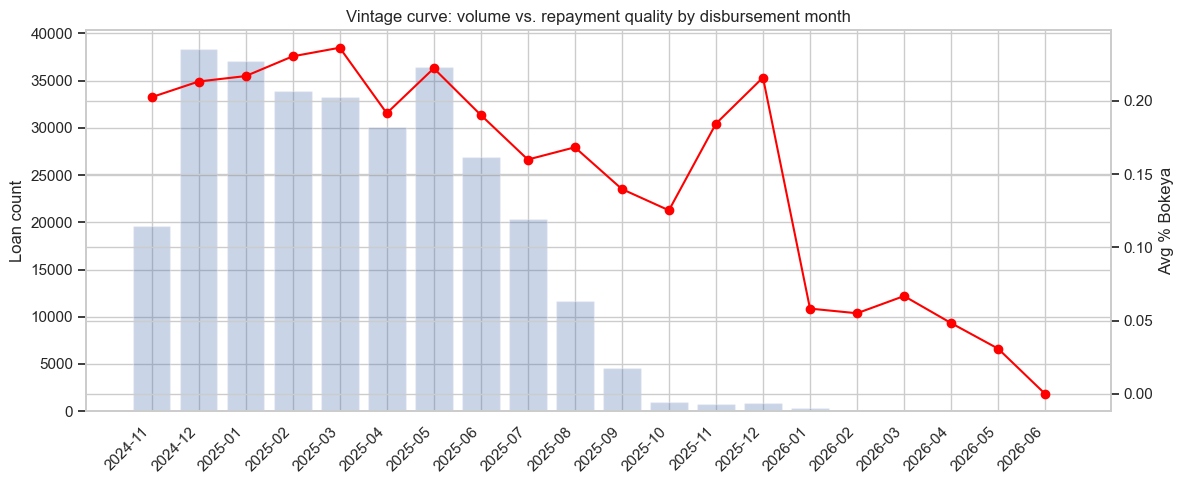

In [156]:
# do newer cohorts perform worse than older ones?

if 'disbursed_date' in df.columns:
    df['disbursed_month'] = pd.to_datetime(df['disbursed_date']).dt.to_period('M')

    vintage = df.groupby('disbursed_month').agg(
        loan_count=('loan_id', 'count'),
        avg_loan_amount=('loan_amount', 'mean'),
        avg_bokeya_pct=('pct_Bokeya', 'mean'),
        total_value=('loan_amount', 'sum')
    )

    print("\nVintage summary (most recent 12 months):")
    print(vintage.tail(12))

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.bar(vintage.index.astype(str), vintage['loan_count'], alpha=0.3, label='Loan count')
    ax1.set_ylabel('Loan count')
    ax2 = ax1.twinx()
    ax2.plot(vintage.index.astype(str), vintage['avg_bokeya_pct'], color='red', marker='o', label='Avg % Bokeya')
    ax2.set_ylabel('Avg % Bokeya')
    plt.title('Vintage curve: volume vs. repayment quality by disbursement month')
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()